Name    : Shubhajeet Das <br />
Roll No.: 24AI10013

# Assignment


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os
print(os.listdir())
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

['.config', 'sample_data']
cuda:0


## Image to Image Translation using cyclic GAN

In [2]:
%%bash
wget https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/summer2winter_yosemite.zip
unzip summer2winter_yosemite.zip

Archive:  summer2winter_yosemite.zip
   creating: summer2winter_yosemite/
   creating: summer2winter_yosemite/trainA/
  inflating: summer2winter_yosemite/trainA/2014-07-01 10:31:48.jpg  
  inflating: summer2winter_yosemite/trainA/2015-07-01 23:43:46.jpg  
  inflating: summer2winter_yosemite/trainA/2014-07-27 21:50:52.jpg  
  inflating: summer2winter_yosemite/trainA/2016-09-12 21:34:08.jpg  
  inflating: summer2winter_yosemite/trainA/2015-06-10 23:35:46.jpg  
  inflating: summer2winter_yosemite/trainA/2016-07-12 13:57:26.jpg  
  inflating: summer2winter_yosemite/trainA/2014-05-13 02:35:47.jpg  
  inflating: summer2winter_yosemite/trainA/2015-07-12 20:23:26.jpg  
  inflating: summer2winter_yosemite/trainA/2015-08-26 00:23:12.jpg  
  inflating: summer2winter_yosemite/trainA/2011-05-19 11:26:37.jpg  
  inflating: summer2winter_yosemite/trainA/2014-08-12 11:31:02.jpg  
  inflating: summer2winter_yosemite/trainA/2016-06-22 11:18:33.jpg  
  inflating: summer2winter_yosemite/trainA/2014-08-12 

--2026-04-08 13:48:19--  https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/summer2winter_yosemite.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 132640856 (126M) [application/zip]
Saving to: ‘summer2winter_yosemite.zip’

     0K .......... .......... .......... .......... ..........  0%  296K 7m18s
    50K .......... .......... .......... .......... ..........  0%  295K 7m18s
   100K .......... .......... .......... .......... ..........  0% 1.46M 5m21s
   150K .......... .......... .......... .......... ..........  0%  369K 5m28s
   200K .......... .......... .......... .......... ..........  0%  108M 4m23s
   250K .......... .......... .......... .......... ..........  0%  279M 3m39s
   300K .......... .......... .......... .......... ..........  0% 1.49M 3m20s
   350K ..........

### Implement a CycleGAN model for unpaired image-to-image translation and evaluate its performance on a real dataset.

## Data Preparation

### Perform preprocessing:

- Resize images (e.g., 256×256)

- Normalize to [-1, 1]

In [15]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os

transforms_ = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset_path = 'summer2winter_yosemite'

# Create datasets for domain A (summer) and domain B (winter)
class CycleGANImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.files = sorted([os.path.join(root, f) for f in os.listdir(root) if f.endswith(('.png', '.jpg', '.jpeg'))])

    def __getitem__(self, index):
        img_path = self.files[index]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img

    def __len__(self):
        return len(self.files)

train_dataset_A = CycleGANImageDataset(root=os.path.join(dataset_path, 'trainA'), transform=transforms_)
train_dataset_B = CycleGANImageDataset(root=os.path.join(dataset_path, 'trainB'), transform=transforms_)
test_dataset_A = CycleGANImageDataset(root=os.path.join(dataset_path, 'testA'), transform=transforms_)
test_dataset_B = CycleGANImageDataset(root=os.path.join(dataset_path, 'testB'), transform=transforms_)

# Define batch size
batch_size = 4

train_dataloader_A = DataLoader(train_dataset_A, batch_size=batch_size, shuffle=True)
train_dataloader_B = DataLoader(train_dataset_B, batch_size=batch_size, shuffle=True)
test_dataloader_A = DataLoader(test_dataset_A, batch_size=batch_size, shuffle=False)
test_dataloader_B = DataLoader(test_dataset_B, batch_size=batch_size, shuffle=False)

print(f"Number of images in trainA: {len(train_dataset_A)}")
print(f"Number of images in trainB: {len(train_dataset_B)}")
print(f"Number of images in testA: {len(test_dataset_A)}")
print(f"Number of images in testB: {len(test_dataset_B)}")

Number of images in trainA: 1231
Number of images in trainB: 962
Number of images in testA: 309
Number of images in testB: 238


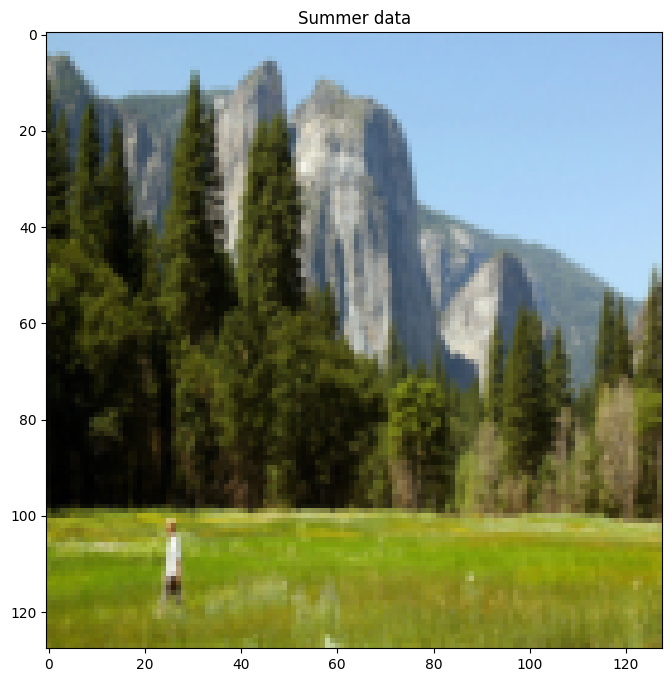

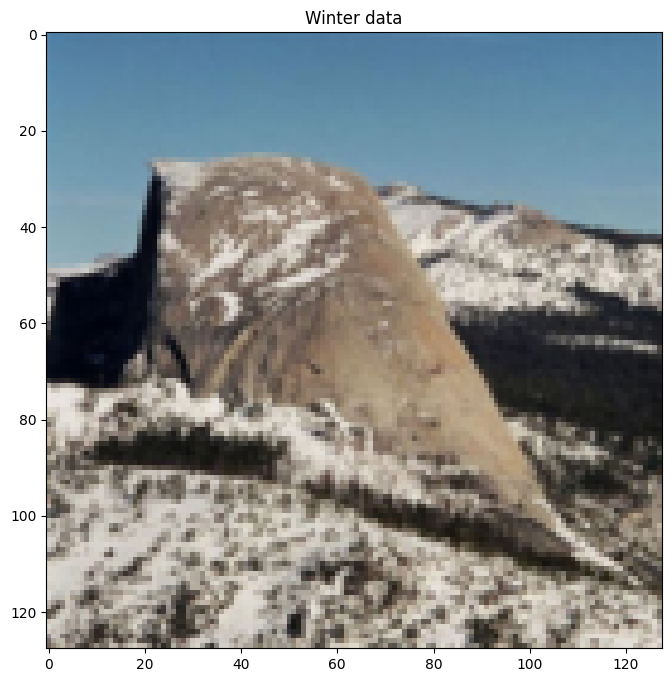

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
transforms_temp = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])
A_dataset = CycleGANImageDataset(root=os.path.join(dataset_path, 'trainA'), transform=transforms_temp)
B_dataset = CycleGANImageDataset(root=os.path.join(dataset_path, 'trainB'), transform=transforms_temp)
a_data = next(iter(A_dataset))
b_data = next(iter(B_dataset))
def imshow(img, label):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(label)
    plt.show()
fig = plt.figure(figsize=(12, 8))
imshow(torchvision.utils.make_grid(a_data), "Summer data")
fig = plt.figure(figsize=(12, 8))
imshow(torchvision.utils.make_grid(b_data), "Winter data")

## Model Architecture

### Generator Network

- Implement ResNet-based generator:

- Downsampling layers

- Residual blocks (at least 6)

- Upsampling layers

### Discriminator Network

- Implement PatchGAN discriminator:

- Convolutional layers

- Outputs patch-level predictions

In [4]:
def conv_block(in_channels , out_channels , kernel_size=4 , strides=2 ,padding_type='reflect' , padding=1 , batch_norm=True):
    layers = []
    if(padding_type=='reflect'):
        pad = nn.ReflectionPad2d(padding)
        layers.append(pad)

    if(padding_type=='replicate'):
        pad = nn.ReplicationPad2d(padding)
        layers.append(pad)


    conv_layer = nn.Conv2d(in_channels=in_channels , out_channels=out_channels , kernel_size=kernel_size , stride=strides , padding=0 ,  bias=False)
    layers.append(conv_layer)
    if(batch_norm):
        bn = nn.InstanceNorm2d(out_channels)
        layers.append(bn)

    return nn.Sequential(*layers)

In [5]:
class Discriminator(nn.Module):
    def __init__(self, conv_dim=64):
        super(Discriminator, self).__init__()
        # PatchGAN: 70x70 discriminator architecture
        # Input: (3, 128, 128)
        self.main = nn.Sequential(
            # Layer 1: 128 -> 64
            nn.Conv2d(3, conv_dim, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2: 64 -> 32
            nn.Conv2d(conv_dim, conv_dim * 2, 4, stride=2, padding=1),
            nn.InstanceNorm2d(conv_dim * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3: 32 -> 16
            nn.Conv2d(conv_dim * 2, conv_dim * 4, 4, stride=2, padding=1),
            nn.InstanceNorm2d(conv_dim * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 4: 16 -> 15 (stride 1)
            nn.Conv2d(conv_dim * 4, conv_dim * 8, 4, stride=1, padding=1),
            nn.InstanceNorm2d(conv_dim * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Output layer: 15 -> 14 (patch-level prediction)
            nn.Conv2d(conv_dim * 8, 1, 4, stride=1, padding=1)
        )

    def forward(self, x):
        return self.main(x)

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super(ResidualBlock, self).__init__()
        self.res_block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3),
            nn.InstanceNorm2d(dim)
        )

    def forward(self, x):
        return x + self.res_block(x)

In [7]:
def deconv_block(in_channels , out_channels , kernel_size=4 , strides=2 , padding=1 , batch_norm=True):
    layers = []
    deconv_layer = nn.ConvTranspose2d(in_channels=in_channels , out_channels=out_channels , kernel_size=kernel_size , stride=strides , padding=padding , bias=False)
    layers.append(deconv_layer)
    if(batch_norm):
        bn = nn.InstanceNorm2d(out_channels)
        layers.append(bn)
    return nn.Sequential(*layers)

In [8]:
class CycleGenerator(nn.Module):
    def __init__(self, conv_dim=64, n_resblocks=9):
        super(CycleGenerator, self).__init__()

        # 1. Initial Convolution
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, conv_dim, 7),
            nn.InstanceNorm2d(conv_dim),
            nn.ReLU(inplace=True)
        ]

        # 2. Downsampling (2 layers)
        curr_dim = conv_dim
        for _ in range(2):
            model += [
                nn.Conv2d(curr_dim, curr_dim * 2, 3, stride=2, padding=1),
                nn.InstanceNorm2d(curr_dim * 2),
                nn.ReLU(inplace=True)
            ]
            curr_dim *= 2

        # 3. Residual Blocks (at least 6, usually 9 for 128x128+)
        for _ in range(n_resblocks):
            model += [ResidualBlock(curr_dim)]

        # 4. Upsampling (2 layers)
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(curr_dim, curr_dim // 2, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(curr_dim // 2),
                nn.ReLU(inplace=True)
            ]
            curr_dim //= 2

        # 5. Output Layer
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(curr_dim, 3, 7),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

In [9]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if(classname.find('Conv') != -1):
        torch.nn.init.normal(m.weight.data , 0.0 , 0.02)
    elif(classname.find('Batchnorm2d')!= -1):
        torch.nn.init.normal(m.weight.data , 0.0 , 0.02)
        torch.nn.init.constant(m.bias.data , 0.0)

In [10]:
def create_model(g_conv_dim=64, d_conv_dim=64, n_resblocks=9, device=device):
    G_X2Y = CycleGenerator(g_conv_dim, n_resblocks).to(device)
    G_Y2X = CycleGenerator(g_conv_dim, n_resblocks).to(device)
    D_X = Discriminator(d_conv_dim).to(device)
    D_Y = Discriminator(d_conv_dim).to(device)

    G_X2Y.apply(weights_init_normal)
    G_Y2X.apply(weights_init_normal)
    D_X.apply(weights_init_normal)
    D_Y.apply(weights_init_normal)

    return G_X2Y, G_Y2X, D_X, D_Y

In [ ]:
G_X2Y , G_Y2X , D_X , D_Y = create_model()

/tmp/ipykernel_24/3458431475.py:4: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  torch.nn.init.normal(m.weight.data , 0.0 , 0.02)


### Loss Functions

Implement:

- Adversarial Loss

- Cycle Consistency Loss

- Identity Loss

In [ ]:
criterion_Idt = nn.L1Loss()
def real_mse_loss(D_out):
    return torch.mean((D_out -1)**2)

def fake_mse_loss(D_out):
    return torch.mean(D_out**2)


def cycle_consistency_loss(real_im, reconstructed_im, lambda_weight):
    reconstruct_loss = torch.mean(torch.abs(real_im-reconstructed_im))
    return reconstruct_loss*lambda_weight

def identity_loss(lambda_idt , idt_B ,real_B , idt_A , real_A , lambda_weight):
    if lambda_idt > 0:
        loss_idt_A = criterion_Idt(idt_B, real_B) * lambda_weight * lambda_idt
        loss_idt_B = criterion_Idt(idt_A, real_A) * lambda_weight * lambda_idt
    else:
        loss_idt_A = 0
        loss_idt_B = 0

    return loss_idt_A + loss_idt_B

### Training Loop

Implement training loop:

- Forward pass
- Backward propagation

Optimizer updates

- Adam optimizer
- Learning rate scheduling
- Train for at least 50 epochs

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import MultiStepLR

lr=0.0002
beta1=0.5
beta2= 0.999

g_params = list(G_X2Y.parameters()) + list(G_Y2X.parameters())

g_optimizer   = optim.Adam(g_params, lr, [beta1, beta2])
d_x_optimizer = optim.Adam(D_X.parameters(), lr, [beta1, beta2])
d_y_optimizer = optim.Adam(D_Y.parameters(), lr, [beta1, beta2])

lambda1 = 3500
lambda2 = 8500

#define lr scheduler
g_lr_scheduler = MultiStepLR(g_optimizer, milestones=[lambda1,lambda2], gamma=0.1)
dx_lr_scheduler =MultiStepLR(d_x_optimizer, milestones=[lambda1,lambda2], gamma=0.1)
dy_lr_scheduler = MultiStepLR(d_y_optimizer, milestones=[lambda1,lambda2], gamma=0.1)

In [ ]:
from tqdm.notebook import tqdm
def rescale(x, feature_range=(-1, 1)):
    min, max = feature_range
    x = x * (max - min) + min
    return x

def checkpoint(epoch, G_XtoY, G_YtoX, D_X, D_Y, checkpoint_dir='checkpoints_cyclegan'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    torch.save(G_XtoY.state_dict(), os.path.join(checkpoint_dir, 'G_XtoY.pkl'))
    torch.save(G_YtoX.state_dict(), os.path.join(checkpoint_dir, 'G_YtoX.pkl'))
    torch.save(D_X.state_dict(), os.path.join(checkpoint_dir, 'D_X.pkl'))
    torch.save(D_Y.state_dict(), os.path.join(checkpoint_dir, 'D_Y.pkl'))

def training_loop(dataloader_X, dataloader_Y, n_epochs=50, device=device):
    print_every = 1
    losses = []

    for epoch in range(1, n_epochs + 1):
        d_x_loss_total = 0
        d_y_loss_total = 0
        g_loss_total = 0
        batch_count = 0

        progress_bar = tqdm(zip(dataloader_X, dataloader_Y), desc=f'Epoch {epoch}', total=min(len(dataloader_X), len(dataloader_Y)), colour='blue')

        for images_X, images_Y in progress_bar:
            batch_count += 1
            images_X = rescale(images_X).to(device)
            images_Y = rescale(images_Y).to(device)

            #Train Discriminators
            d_x_optimizer.zero_grad()
            out_x_real = D_X(images_X)
            loss_x_real = real_mse_loss(out_x_real)
            fake_X = G_Y2X(images_Y)
            out_x_fake = D_X(fake_X.detach())
            loss_x_fake = fake_mse_loss(out_x_fake)
            d_x_loss = loss_x_real + loss_x_fake
            d_x_loss.backward()
            d_x_optimizer.step()

            d_y_optimizer.zero_grad()
            out_y_real = D_Y(images_Y)
            loss_y_real = real_mse_loss(out_y_real)
            fake_Y = G_X2Y(images_X)
            out_y_fake = D_Y(fake_Y.detach())
            loss_y_fake = fake_mse_loss(out_y_fake)
            d_y_loss = loss_y_real + loss_y_fake
            d_y_loss.backward()
            d_y_optimizer.step()

            #Train Generators
            g_optimizer.zero_grad()
            out_x_fake_g = D_X(fake_X)
            g_x_loss = real_mse_loss(out_x_fake_g)
            out_y_fake_g = D_Y(fake_Y)
            g_y_loss = real_mse_loss(out_y_fake_g)
            reconstructed_X = G_Y2X(fake_Y)
            cycle_x_loss = cycle_consistency_loss(images_X, reconstructed_X, lambda_weight=10)
            reconstructed_Y = G_X2Y(fake_X)
            cycle_y_loss = cycle_consistency_loss(images_Y, reconstructed_Y, lambda_weight=10)
            idt_X = G_Y2X(images_X)
            idt_Y = G_X2Y(images_Y)
            id_loss = identity_loss(0.5, idt_Y, images_Y, idt_X, images_X, lambda_weight=10)
            g_total_loss = g_x_loss + g_y_loss + cycle_x_loss + cycle_y_loss + id_loss
            g_total_loss.backward()
            g_optimizer.step()

            d_x_loss_total += d_x_loss.item()
            d_y_loss_total += d_y_loss.item()
            g_loss_total += g_total_loss.item()

        g_lr_scheduler.step()
        dx_lr_scheduler.step()
        dy_lr_scheduler.step()

        avg_dx = d_x_loss_total / batch_count
        avg_dy = d_y_loss_total / batch_count
        avg_g = g_loss_total / batch_count
        losses.append((avg_dx, avg_dy, avg_g))

        if epoch % print_every == 0:
            print(f'Epoch [{epoch:5d}/{n_epochs:5d}] | d_X: {avg_dx:6.4f} | d_Y: {avg_dy:6.4f} | G: {avg_g:6.4f}')
            checkpoint(epoch, G_X2Y, G_Y2X, D_X, D_Y)

    return losses

In [ ]:
losses = training_loop(train_dataloader_A, train_dataloader_B, n_epochs=50, device=device)

Epoch 1:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch [    1/   50] | d_X: 0.5995 | d_Y: 0.6156 | G: 28.1823


Epoch 2:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch [    2/   50] | d_X: 0.1329 | d_Y: 0.1154 | G: 27.0674


Epoch 3:   0%|          | 0/241 [00:00<?, ?it/s]

...

Epoch [   48/   50] | d_X: 0.0071 | d_Y: 0.0116 | G: 23.5590


Epoch 49:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch [   49/   50] | d_X: 0.0114 | d_Y: 0.0157 | G: 23.5533


Epoch 50:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch [   50/   50] | d_X: 0.0102 | d_Y: 0.0136 | G: 23.3618


In [11]:
G_X2Y , G_Y2X , D_X , D_Y = create_model()
checkpt_gxtoy = torch.load('/G_XtoY.pkl')
checkpt_gytox = torch.load('/G_YtoX.pkl')
checkpt_dx = torch.load('/D_X.pkl')
checkpt_dy = torch.load('/D_Y.pkl')
G_X2Y.load_state_dict(checkpt_gxtoy)
G_Y2X.load_state_dict(checkpt_gytox)
D_X.load_state_dict(checkpt_dx)
D_Y.load_state_dict(checkpt_dy)

/tmp/ipykernel_1352/3458431475.py:4: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  torch.nn.init.normal(m.weight.data , 0.0 , 0.02)


<All keys matched successfully>

In [12]:
losses = [
    (0.5995, 0.6156, 28.1823),
    (0.1329, 0.1154, 27.0674),
    (0.0779, 0.0906, 26.5037),
    (0.0624, 0.0687, 26.2458),
    (0.0620, 0.0690, 25.9810),
    (0.0556, 0.0493, 25.7491),
    (0.0452, 0.0529, 25.5890),
    (0.0463, 0.0506, 25.4660),
    (0.0376, 0.0614, 25.4164),
    (0.0364, 0.0386, 25.2124),
    (0.0353, 0.0316, 25.1943),
    (0.1128, 0.0410, 25.0816),
    (0.0138, 0.0437, 25.0406),
    (0.0207, 0.0379, 24.8533),
    (0.0336, 0.0299, 24.8814),
    (0.0301, 0.0330, 24.7923),
    (0.0226, 0.0324, 24.7874),
    (0.0271, 0.0320, 24.6530),
    (0.0248, 0.0248, 24.6718),
    (0.0234, 0.0325, 24.5745),
    (0.2565, 0.0529, 24.6428),
    (0.1439, 0.0170, 24.3733),
    (0.0225, 0.0330, 24.3089),
    (0.0169, 0.0168, 24.4173),
    (0.0166, 0.0158, 24.4352),
    (0.0211, 0.0279, 24.3617),
    (0.0239, 0.0216, 24.1784),
    (0.0182, 0.3070, 24.2171),
    (0.0187, 0.0210, 24.1020),
    (0.0170, 0.0113, 24.0589),
    (0.0312, 0.0115, 24.0360),
    (0.0154, 0.0171, 23.9934),
    (0.0158, 0.0198, 24.0780),
    (0.0219, 0.0378, 23.9911),
    (0.0121, 0.0187, 23.8046),
    (0.0216, 0.0143, 23.7854),
    (0.0142, 0.0231, 23.9300),
    (0.0115, 0.0216, 23.9495),
    (0.0247, 0.0511, 23.7223),
    (0.1400, 0.0063, 23.7623),
    (0.0118, 0.3072, 23.8736),
    (0.0096, 0.0163, 23.7305),
    (0.0096, 0.0084, 23.5350),
    (0.0290, 0.0052, 23.6328),
    (0.0065, 0.0048, 23.7548),
    (0.0052, 0.0066, 23.6592),
    (0.0213, 0.0138, 23.5261),
    (0.0071, 0.0116, 23.5590),
    (0.0114, 0.0157, 23.5533),
    (0.0102, 0.0136, 23.3618)
]

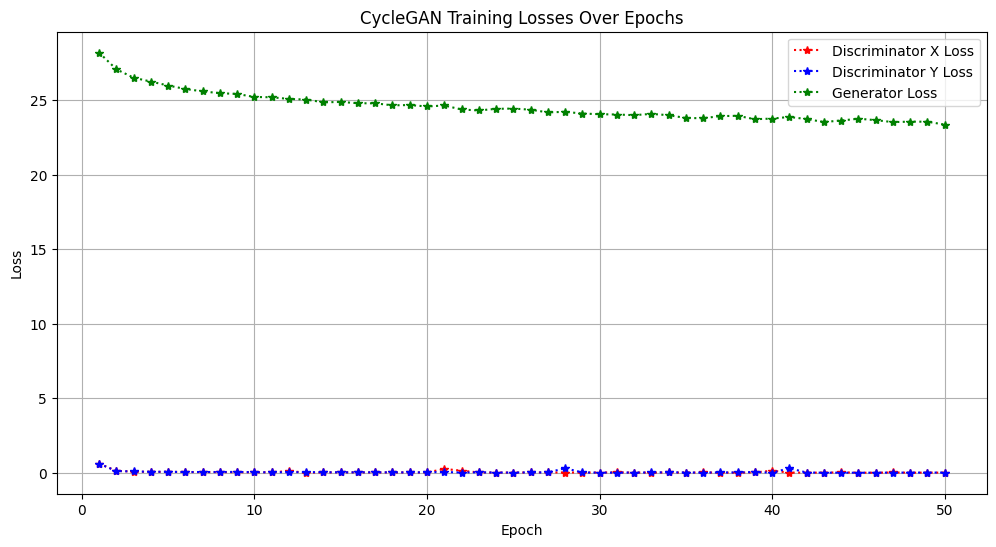

In [13]:
import matplotlib.pyplot as plt

d_x_losses = [l[0] for l in losses]
d_y_losses = [l[1] for l in losses]
g_losses = [l[2] for l in losses]
epochs = range(1, len(losses) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs, d_x_losses,color='red', linestyle=':', marker='*', label='Discriminator X Loss')
plt.plot(epochs, d_y_losses,color='blue', linestyle=':', marker='*', label='Discriminator Y Loss')
plt.plot(epochs, g_losses,color='green', linestyle=':', marker='*', label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CycleGAN Training Losses Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation & Analysis

### Evaluate:
- Visual quality
- Consistency

Summer to Winter Translation:


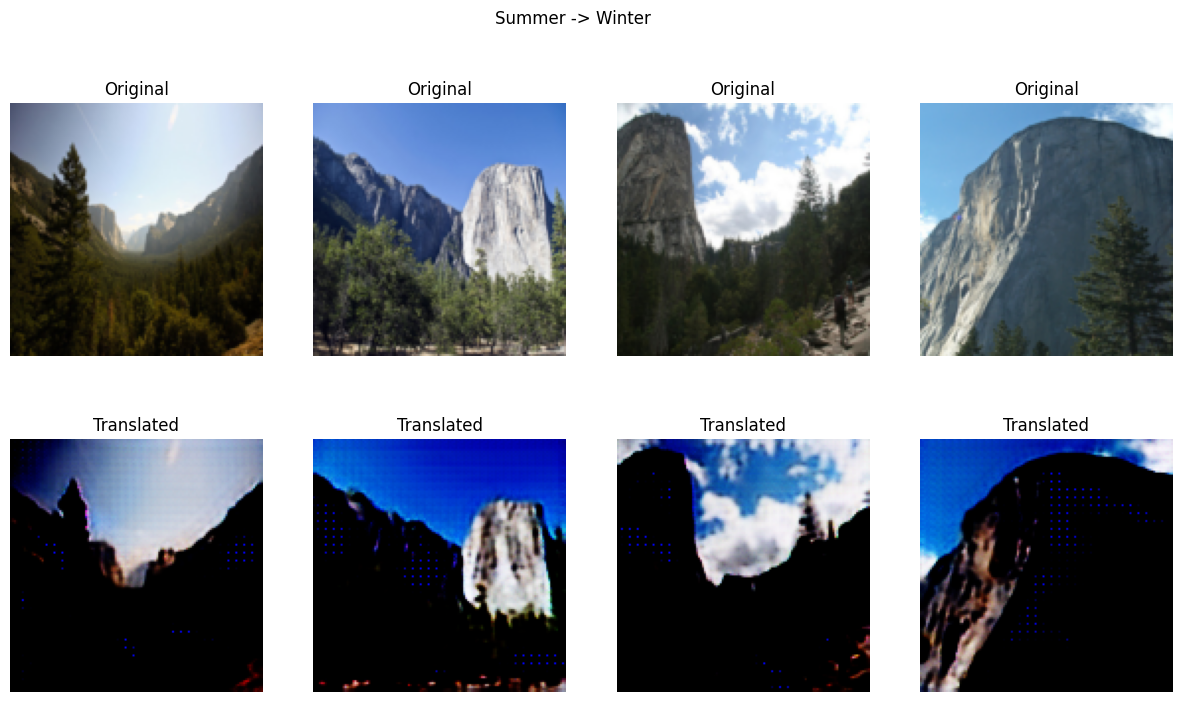

Winter to Summer Translation:


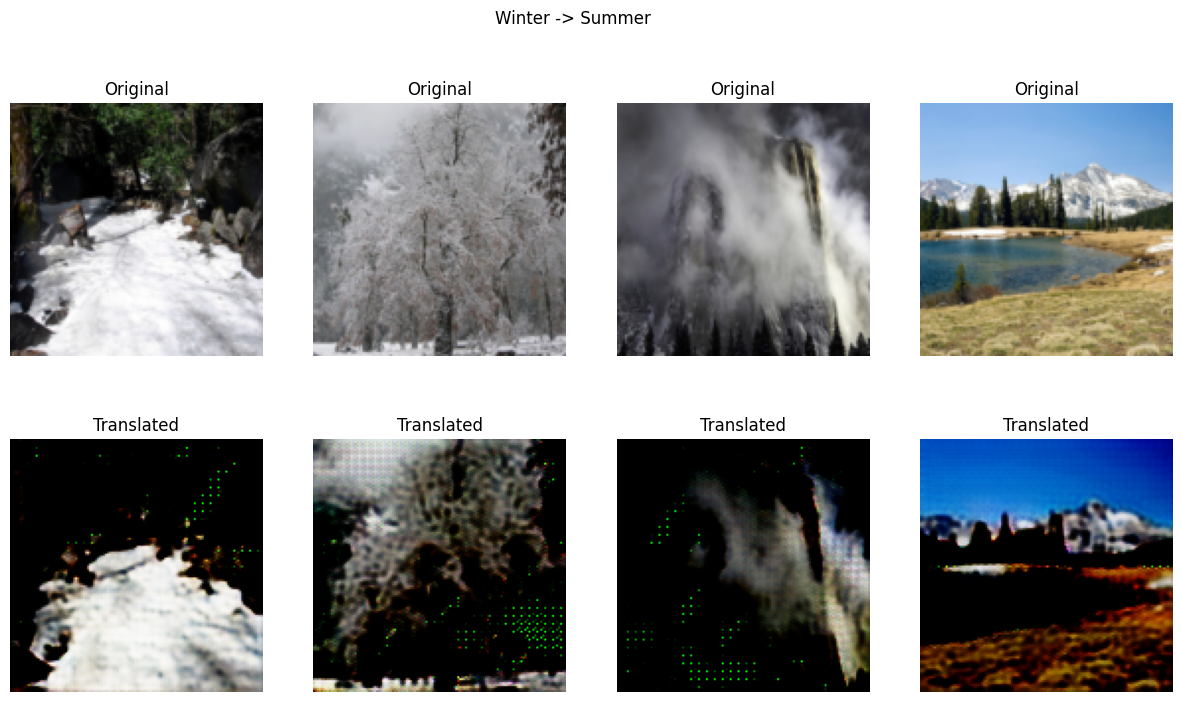

In [17]:
import numpy as np
def visualize_results(dataloader, generator, title, device=device, num_samples=4):
    generator.eval()
    images = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        fake_images = generator(images)

    images = (images + 1) / 2
    fake_images = (fake_images + 1) / 2

    images = images.cpu().numpy()
    fake_images = fake_images.cpu().numpy()

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 8))
    for i in range(num_samples):
        axes[0, i].imshow(np.transpose(images[i], (1, 2, 0)))
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        axes[1, i].imshow(np.transpose(fake_images[i], (1, 2, 0)))
        axes[1, i].set_title("Translated")
        axes[1, i].axis('off')

    plt.suptitle(title)
    plt.show()

print("Summer to Winter Translation:")
visualize_results(test_dataloader_A, G_X2Y, "Summer -> Winter")

print("Winter to Summer Translation:")
visualize_results(test_dataloader_B, G_Y2X, "Winter -> Summer")

### Discuss:
- Strengths of model
- Failure cases

### Discussion

**Strengths of the Model:**
- **Unpaired Translation:** The CycleGAN effectively learns to translate between domains without requiring one-to-one paired training data.
- **Cycle Consistency:** The cycle-consistency loss ensures that the structural integrity of the images is preserved (e.g., the shapes of mountains and trees remain consistent).
- **Style Transfer:** The model successfully captures global color distributions, turning green summer foliage into white snow-covered landscapes and vice versa.

**Failure Cases / Limitations:**
- **Geometric Changes:** CycleGAN struggles with tasks requiring significant geometric changes (e.g., adding large amounts of physical snow rather than just changing color).
- **Artifacts:** Occasionally, 'checkerboard' artifacts or unnatural color spots may appear due to the transposed convolution layers.